In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [14]:
import re
with open("nalgae.txt", "r", encoding="utf-8") as f:
    text = f.read().replace(" ", "_")
text = re.sub(r'[^0-9가-힣.,!?_\-()(···)"\'\n]', ' ', text)
len(text)

21457

In [15]:
bag_of_word = list(set(text))
itos = {i:s for i, s in enumerate(bag_of_word)}
stoi = {s:i for i, s in enumerate(bag_of_word)} 
total_tokens = len(bag_of_word)
itos[stoi["안"]]

'안'

In [16]:
def make_chunks(data, n=5):
    for ptr in range(0, len(data)-n-1):
        yield data[ptr:ptr+n+1]

n = 6
chunks = [chunk for chunk in make_chunks(text, n)]

In [17]:
def tokenize(chunk):
    return [stoi[char] for char in chunk]

def stringfy(tokens):
    return "".join([itos[token] for token in tokens])

print("Tokens:", tokenize(chunks[0]))
print("String:", stringfy(tokenize(chunks[0])))

Tokens: [647, 486, 525, 525, 702, 456, 525]
String: 날개

이상



In [18]:
import random

def beautiful_f(x):
    return random.randint(0, total_tokens)

def generate(x, function, max_length=100, **kwrgs):
    for i in range(len(x), max_length):
        x += stringfy([function(x[i-n:i], **kwrgs)])
    return x

chunk = chunks[0]
x = chunk[:n]
y = chunk[n]
print(generate(x, beautiful_f))

날개

이상털면옳끌념외졸잉움시굽몇증크돌께황깬뻗훨계범효됐결채독챌칼머숨멱리럭직빌쨌쨌교라켓둑녔밉웃빼데설감속?총버러불최_덕당위덤짚수받바튿숨북몽는좀항랐옥스쏟짚싸둔메맡배쁨맸너곤커음곁곱삭삭"속


In [379]:
w = torch.tensor([1, 2, 3], requires_grad=True, dtype=torch.float)
x = torch.tensor([2, 1, 3], requires_grad=False, dtype=torch.float)
y = w@x

In [380]:
w.grad

In [381]:
y.backward()
w.grad

tensor([2., 1., 3.])

In [382]:
node = y.grad_fn

In [383]:
def walk(node, depth=0):
    print(".." * depth + f"{node}")
    for fn, _ in node.next_functions:
        if fn is not None:
            walk(fn, depth + 1)

loss = y  # 위 예시에서
walk(loss.grad_fn)

..<AccumulateGrad object at 0x357ddc040>


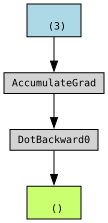

In [384]:
from torchviz import make_dot
make_dot(loss)

In [ ]:
class MySquare(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x):
        ctx.save_for_backward(x)
        return x * x

    @staticmethod
    def backward(ctx, grad_out):
        x, = ctx.saved_tensors
        # chain rule: dL/dx = (dL/dy) * (dy/dx)
        print(grad_out)
        return grad_out * (2 * x)

w = torch.tensor([1, 2, 3], requires_grad=True, dtype=torch.float)
x = torch.tensor([2, 1, 3], requires_grad=False, dtype=torch.float)
y = w@x
loss = MySquare.apply(y)
print(loss)
# y.retain_grad()

# loss.backward()
print(w.grad, y.grad)

tensor(169., grad_fn=<MySquareBackward>)
None None


/var/folders/wk/7qx0rv3n58lbj8js8tqzyn8m0000gn/T/ipykernel_62775/1446521426.py:22: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/build/aten/src/ATen/core/TensorBody.h:494.)
  print(w.grad, y.grad)


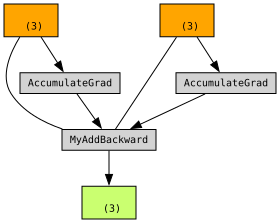

In [394]:
class MyAdd(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, y):
        ctx.save_for_backward(x, y)
        return x + y

    @staticmethod
    def backward(ctx, grad_out):
        x, y = ctx.saved_tensors
        return grad_out * torch.ones_like(x),  grad_out * torch.ones_like(y)

class my_tensor():
    def __init__(self, t):
        self.t = t
    def __add__(self, x):
        return MyAdd.apply(self.t, x.t)


w = my_tensor(torch.tensor([1., 2., 3.], requires_grad=True, dtype=torch.float))
x = my_tensor(torch.tensor([2., 1., 3.], requires_grad=True, dtype=torch.float))
loss = w + x

make_dot(loss)

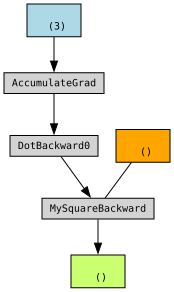

In [ ]:
make_dot(loss)

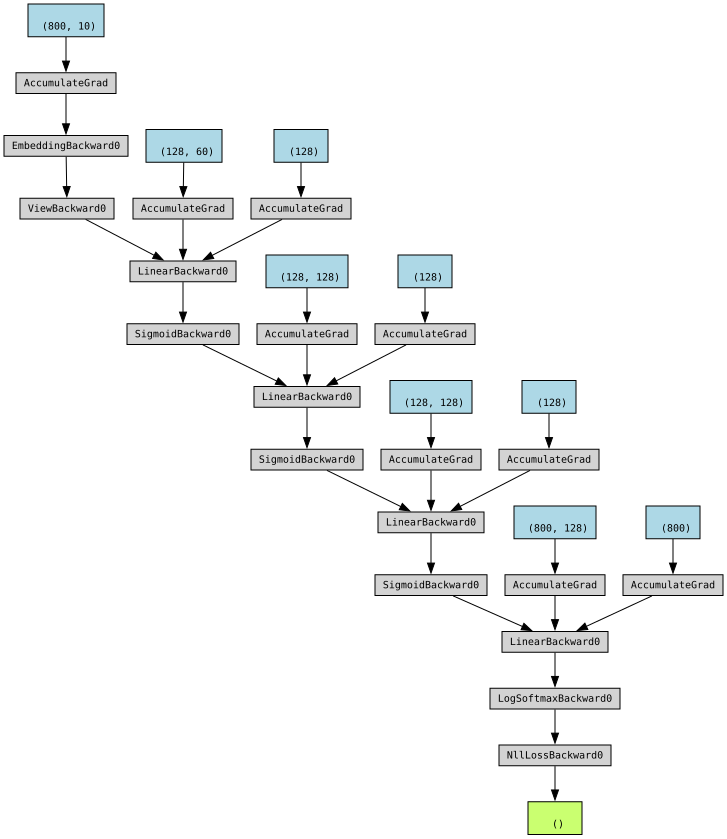

In [378]:
loss = F.cross_entropy(my_first_model(inds), ground_truths)
# walk(loss.grad_fn)
make_dot(loss)

In [ ]:
print(torch.add)
import inspect
print(torch.Tensor.__add__)

<built-in method add of type object at 0x10bdd8c58>
<method '__add__' of 'torch._C.TensorBase' objects>


In [311]:
import torch.autograd
dir(torch.autograd)

['Any',
 'Callable',
 'DeviceType',
 'Function',
 'List',
 'NestedIOFunction',
 'Optional',
 'ProfilerActivity',
 'ProfilerConfig',
 'ProfilerEvent',
 'ProfilerState',
 'SavedTensor',
 'Sequence',
 'Tuple',
 'Union',
 'Variable',
 '_KinetoEvent',
 '_OptionalTensor',
 '_ProfilerResult',
 '_ShapeorNestedShape',
 '_TensorOrTensors',
 '_TensorOrTensorsOrGradEdge',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_add_metadata_json',
 '_calculate_shape',
 '_disable_profiler',
 '_disable_profiler_legacy',
 '_enable_profiler',
 '_enable_profiler_legacy',
 '_enable_record_function',
 '_engine_run_backward',
 '_force_original_view_tracking',
 '_get_sequence_nr',
 '_is_checkpoint_valid',
 '_kineto_step',
 '_make_grads',
 '_pop_saved_tensors_default_hooks',
 '_prepare_profiler',
 '_profiler_enabled',
 '_push_saved_tensors_default_hooks',
 '_record_function_with_args_enter',
 '_record_function_with_args_exi

In [293]:
import torch
from torch.profiler import profile, record_function, ProfilerActivity

x = torch.randn(1024, 1024, requires_grad=True)
w = torch.randn(1024, 1024, requires_grad=True)

with profile(activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA], record_shapes=True) as prof:
    with record_function("linear layer"):
        y = x @ w
        y.sum().backward()

print(prof.key_averages().table(sort_by="cuda_time_total", row_limit=10))


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                           linear layer        17.68%       3.436ms       100.00%      19.431ms      19.431ms             1  
                                           aten::matmul         0.06%      12.292us        31.13%       6.048ms       6.048ms             1  
                                               aten::mm        55.81%      10.844ms        60.08%      11.675ms       3.892ms             3  
                                     aten::resolve_conj         0.01%       1.291us         0.01%       1.291us       0.258us             5  
      

/Users/ysh/miniforge3/envs/mlenv/lib/python3.11/site-packages/torch/autograd/profiler.py:257: UserWarning: CUDA is not available, disabling CUDA profiling
  warn("CUDA is not available, disabling CUDA profiling")


In [ ]:
import tqdm

emb_size = 10
Emb = torch.randn((total_tokens, emb_size))
W = torch.randn((n*emb_size, total_tokens)) / 100
B = torch.zeros((total_tokens,))
parameters = [Emb, W, B]
for p in parameters:
    p.requires_grad = True

losses = []
small_batch = 1024
# epoch
for epoch in tqdm.trange(100000):
    # batch
    inds = []
    gts = []
    for i in range(small_batch):
        chunk = random.choice(chunks)
        ground_truth = tokenize(chunk)[n]
        indexs = tokenize(chunk)[:n]
        inds.append(indexs)
        gts.append(ground_truth)

inds = torch.tensor(inds, dtype=torch.int)
gts = torch.tensor(gts, dtype=torch.long)
x = Emb[inds].reshape(small_batch, -1)
y = x @ W + B
exped = torch.exp(y-y.max())
softmaxed = exped / torch.sum(exped, axis=-1).view(-1, 1)
loss = (-torch.log2(softmaxed[range(small_batch), gts])).mean()
loss.backward()

if epoch % 1000 == 0:
    # print(-torch.log2(softmaxed[range(small_batch), gts]), softmaxed[range(small_batch), gts])
    # print(exped, x, W, B)
    pred = torch.argmax(y[0]).item()
    print(f"{chunk[:n]} -> {chunk[n]}")
    print("Entropy Error:", loss.item(), "Prediction:", itos[pred])
if epoch % 50 == 0:
    losses.append(loss.item())

    # optimizer
    lr = 1e-3
    for p in parameters:
        p.data -= lr * p.grad
        p.grad = None

Text(0.5, 0, 'epoch')

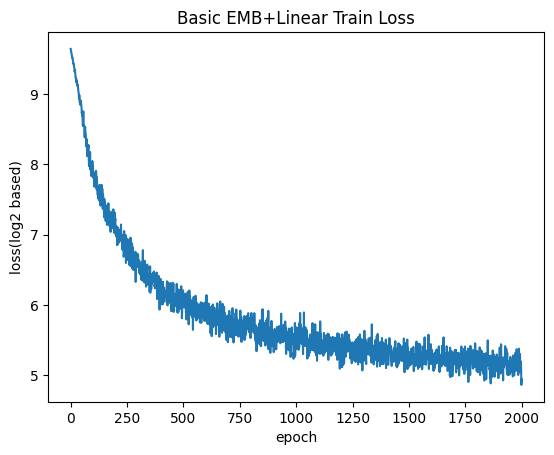

In [129]:
import matplotlib.pyplot as plt

plt.plot(range(len(losses)), losses)
plt.title("Basic EMB+Linear Train Loss")
plt.ylabel("loss(log2 based)")
plt.xlabel("epoch")

In [133]:
def logistic(x):
    indexs = tokenize(x.replace(" ", "_"))
    x = Emb[indexs].reshape(1, -1)
    y = x @ W + B
    return torch.multinomial(F.softmax(y, dim=1), 1)[0].item()
generate("박제가_되어버린_", logistic, max_length=50)

'박제가_되어버린_들간내_높명농찰_당가_아적지_떨고_작상은_랗어_다면_그커분린다._아내주낯_'

In [ ]:
import tqdm

device = "mps"

emb_size = 100
Emb = torch.randn((total_tokens, emb_size), device=device)
W = torch.randn((n*emb_size, total_tokens), device=device) / 100
B = torch.zeros((total_tokens,), device=device)
parameters = [Emb, W, B]
for p in parameters: p.requires_grad_()
optimizer = optim.SGD(parameters, lr=1e-3)

losses = []
small_batch = 128
token_chunks = torch.tensor([tokenize(chunk) for chunk in chunks], dtype=torch.long, device=device)

def dataload():
    chosen = torch.randint(0, len(token_chunks), (small_batch,), device=device)
    inds = token_chunks[chosen][..., :n]
    ground_truths = token_chunks[chosen][..., n]
    return inds, ground_truths

In [ ]:
my_first_model = nn.Sequential(
    nn.Embedding(total_tokens, emb_size),
    nn.Flatten(),
    nn.Linear(emb_size*n, total_tokens)
).to(device)

optimizer = optim.SGD(my_first_model.parameters(), lr=1e-3)

In [273]:
for epoch in tqdm.trange(10000):
    inds, ground_truths = dataload()
    # x = Emb[inds].reshape(small_batch, -1)
    # y = x @ W + B
    y = my_first_model(inds)
    loss = F.cross_entropy(y, ground_truths)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 1000 == 0:
        pred = torch.argmax(y[0]).item()
        x = inds[0].detach().cpu().tolist()
        gt = ground_truths[0].item()
        print(f"{stringfy(x)} -> {stringfy([gt])}")
        print("Entropy Error:", loss.item(), "Prediction:", itos[pred])
    if epoch % 50 == 0:
        losses.append(loss.item())

  0%|          | 46/10000 [00:00<00:41, 240.50it/s]

에_각기_빌 -> 어
Entropy Error: 1.313927173614502 Prediction: 어


 11%|█         | 1052/10000 [00:03<00:27, 325.99it/s]

긁었다._쓰 -> 라
Entropy Error: 0.8439977765083313 Prediction: 라


 21%|██        | 2055/10000 [00:06<00:26, 297.44it/s]

...

 81%|████████  | 8056/10000 [00:26<00:05, 334.26it/s]

은_대체_귀 -> 찮
Entropy Error: 0.5942330956459045 Prediction: 찮


 91%|█████████ | 9057/10000 [00:29<00:02, 336.09it/s]

밥이_목으로 -> _
Entropy Error: 0.7645993828773499 Prediction: _


100%|██████████| 10000/10000 [00:32<00:00, 307.56it/s]


In [274]:
def logistic(x):
    indexs = torch.tensor(tokenize(x.replace(" ", "_")), dtype=torch.long, device=device)
    y = my_first_model(indexs[None, :])
    return torch.multinomial(F.softmax(y, dim=1), 1)[0].item()
generate("박제가_되어버린_", logistic, max_length=50)

'박제가_되어버린_것이다.\n나는_그러나_나는_또_그랬을_느하였다.\n우선_두부자리도_맹가_분제'

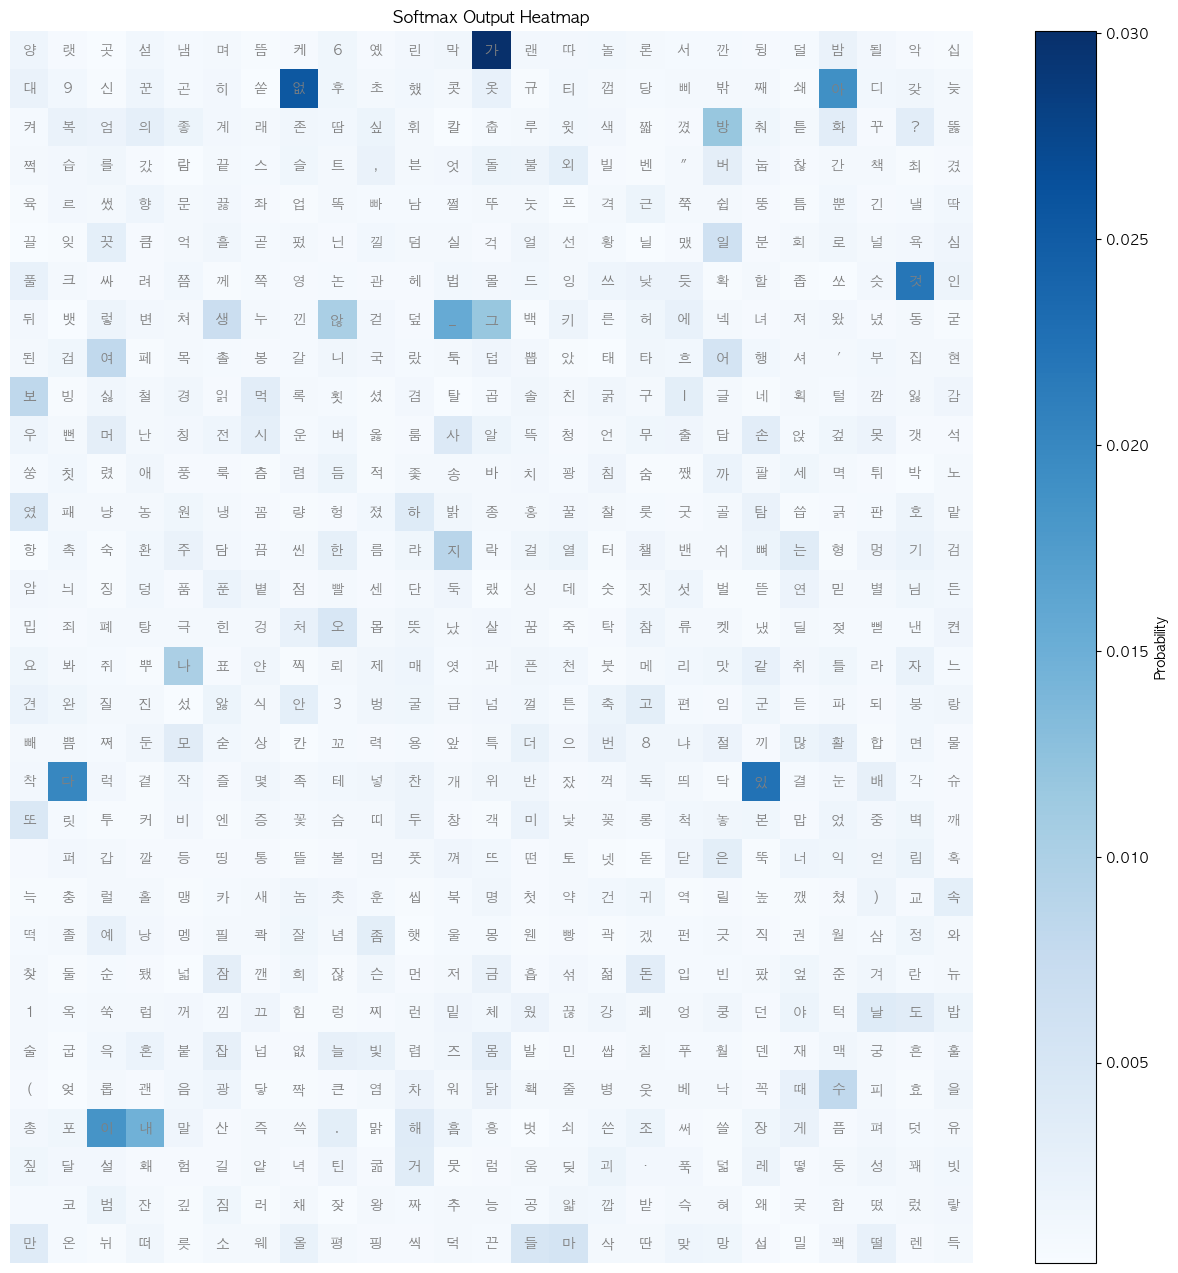

In [202]:
x = torch.tensor(tokenize("이상_날개_"), dtype=torch.long, device=device).unsqueeze(0)

with torch.no_grad():
    softmaxed = F.softmax(my_first_model(x), dim=1).cpu().numpy()

plt.rcParams["font.family"] = "AppleGothic"
plt.figure(figsize=(16, 16))
plt.imshow(softmaxed.reshape(32, 25), cmap="Blues")
plt.colorbar(label="Probability")
plt.title("Softmax Output Heatmap")
plt.axis("off")
for i in range(32):
    for j in range(25):
        chstr = itos[i*25+j]
        plt.text(j, i, chstr, ha="center", va="center", color="gray")

In [255]:
my_first_model = nn.Sequential(
    nn.Embedding(total_tokens, 10),
    nn.Flatten(),
    nn.Linear(10*n, 128),
    nn.Sigmoid(),
    nn.Linear(128, 128),
    nn.Sigmoid(),
    nn.Linear(128, 128),
    nn.Sigmoid(),
    nn.Linear(128, total_tokens)
).to(device)
optimizer = optim.Adam(my_first_model.parameters(), lr=1e-3)

In [277]:
for epoch in tqdm.trange(10000):
    inds, ground_truths = dataload()
    y = my_first_model(inds)
    loss = F.cross_entropy(y, ground_truths)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 1000 == 0:
        pred = torch.argmax(y[0]).item()
        x = inds[0].detach().cpu().tolist()
        gt = ground_truths[0].item()
        print(f"{stringfy(x)} -> {stringfy([gt])}")
        print("Entropy Error:", loss.item(), "Prediction:", itos[pred])
    if epoch % 50 == 0:
        losses.append(loss.item())

  1%|          | 54/10000 [00:00<00:35, 277.08it/s]

없다._그러 -> 나
Entropy Error: 0.5415676832199097 Prediction: 나


 11%|█         | 1061/10000 [00:03<00:26, 332.09it/s]

모른다._다 -> 만
Entropy Error: 0.6216352581977844 Prediction: 만


 21%|██        | 2055/10000 [00:06<00:26, 298.84it/s]

...

 80%|████████  | 8033/10000 [00:24<00:06, 318.60it/s]

_재웠을까? -> _
Entropy Error: 0.27524057030677795 Prediction: _


 90%|█████████ | 9042/10000 [00:27<00:02, 329.07it/s]

니_겁도_났 -> 으
Entropy Error: 0.4328788220882416 Prediction: 으


100%|██████████| 10000/10000 [00:30<00:00, 325.13it/s]


In [280]:
def logistic(x):
    indexs = torch.tensor(tokenize(x.replace(" ", "_")), dtype=torch.long, device=device)
    y = my_first_model(indexs[None, :])
    return torch.argmax(F.softmax(y, dim=1), 1)[0].item()
generate("박제가_되어버린_", logistic, max_length=300)

'박제가_되어버린_것이_앉아_잘난_물아_아간_보았다._그_오원_돈을_꺼내_아내_손에_쥐어지는_것이_있었다._나는_이불을_뒤집어썼다._한_번도_구경한_일이_없으나_언제든지_끼니_때면_내_방으로_가서_쭉_빠진_옷을_활활_벗어_버리고도_싶었다.\n나는_내_잘못된_생각을_거기져_풍마한_것이다._그러나_그것은_이불_속에_있었다._나는_이불을_뒤집어썼다._한_번도_구경한_일이_없으나_언제든지_끼니_때면_내_방으로_가서_쭉_빠진_옷을_활활_벗어_버리고도_싶었다.\n나는_내_잘못된_생각을_거기져_풍마한_것이다._그러나_그것은_이불_속에_있었다._나는_'

(array([[0., 0., 0., ..., 4., 1., 1.],
        [0., 0., 4., ..., 2., 0., 0.],
        [0., 0., 0., ..., 1., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 1., 1., ..., 1., 0., 0.],
        [0., 0., 0., ..., 4., 2., 1.]]),
 array([-0.00946602, -0.0077288 , -0.00599158, -0.00425436, -0.00251714,
        -0.00077992,  0.0009573 ,  0.00269452,  0.00443174,  0.00616896,
         0.00790618]),
 <a list of 128 BarContainer objects>)

/Users/ysh/miniforge3/envs/mlenv/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  func(*args, **kwargs)
/Users/ysh/miniforge3/envs/mlenv/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


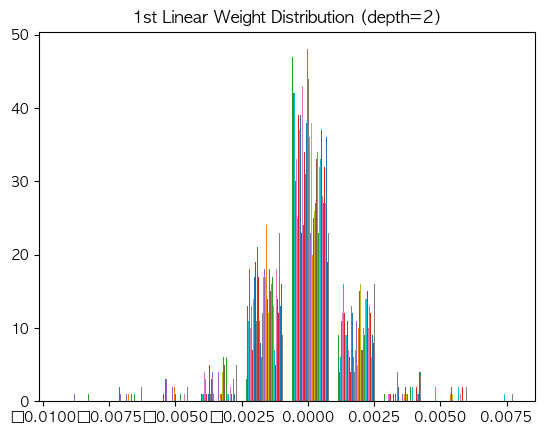

In [246]:
plt.title("1st Linear Weight Distribution (depth=2)")
plt.hist(my_first_model[2].weight.grad.cpu())

(array([[0., 0., 2., ..., 2., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 1., 1., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 1., 0., 0.]]),
 array([-2.82796100e-06, -2.27945998e-06, -1.73095918e-06, -1.18245816e-06,
        -6.33957256e-07, -8.54563496e-08,  4.63044586e-07,  1.01154546e-06,
         1.56004648e-06,  2.10854728e-06,  2.65704830e-06]),
 <a list of 128 BarContainer objects>)

/Users/ysh/miniforge3/envs/mlenv/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  func(*args, **kwargs)
/Users/ysh/miniforge3/envs/mlenv/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


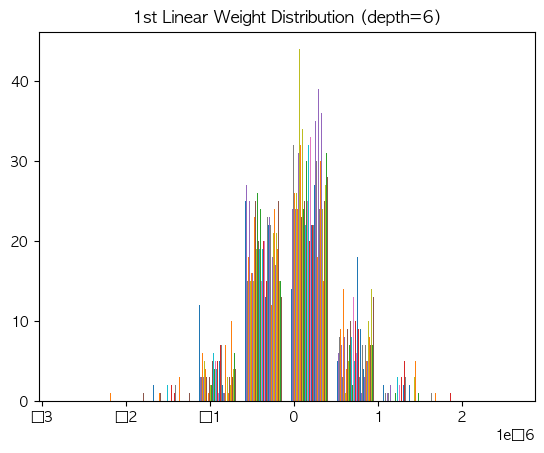

In [249]:
plt.title("1st Linear Weight Distribution (depth=6)")
plt.hist(my_first_model[2].weight.grad.cpu())

In [396]:
generate("박제가_되어버린_", logistic, max_length=300)

'박제가_되어버린_것이_앉아_잘난_물아_아간_보았다._그_오원_돈을_꺼내_아내_손에_쥐어지는_것이_있었다._나는_이불을_뒤집어썼다._한_번도_구경한_일이_없으나_언제든지_끼니_때면_내_방으로_가서_쭉_빠진_옷을_활활_벗어_버리고도_싶었다.\n나는_내_잘못된_생각을_거기져_풍마한_것이다._그러나_그것은_이불_속에_있었다._나는_이불을_뒤집어썼다._한_번도_구경한_일이_없으나_언제든지_끼니_때면_내_방으로_가서_쭉_빠진_옷을_활활_벗어_버리고도_싶었다.\n나는_내_잘못된_생각을_거기져_풍마한_것이다._그러나_그것은_이불_속에_있었다._나는_'